<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/FL%20TreeGMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Federated Learning via Synthetic Data Exchange (Tree Models)

This notebook implements a **data‑centric** federated learning approach:

1. Each client trains a Random Forest (RF) on its private data.
2. Clients generate synthetic data using a **Gaussian Mixture Model (GMM)** fitted to their real data, then label it with their RF.
3. Clients upload synthetic data (optionally with **Laplace differential privacy noise**) to the server.
4. The server aggregates all synthetic data and trains a global RF.
5. The server generates a large pool of global synthetic data, then sends **proportional subsets** back to each client.
6. Clients merge this synthetic data with their real data for the next round.

**No model parameters are shared** – only synthetic data. This is a privacy‑preserving alternative to FedAvg for tree models.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, fetch_openml, fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

## Configuration Parameters Explained

| Parameter | Meaning |
|-----------|---------|
| `DATASET` | Choose from `breast_cancer`, `a9a`, `cod_rna`, `covertype`. The `a9a` (adult) dataset is used here. |
| `NUM_CLIENTS` | Number of simulated federated clients. |
| `NUM_ROUNDS` | Number of communication rounds. |
| `SYNTHETIC_SAMPLES_PER_CLIENT` | How many synthetic samples each client generates per round. |
| `SYNTHETIC_SAMPLES_FROM_GLOBAL` | Total synthetic samples the server generates (then split proportionally among clients). |
| `DP_EPSILON` | Privacy budget for Laplace DP. `None` = no noise. Lower = more privacy but lower accuracy. |


Dataset Overview :
- **breast_cancer** (small, 569 samples) – fast for testing.
- **a9a** (medium, ~32k samples, 123 features) – realistic tabular.
- **cod_rna** (medium, ~60k samples, 8 features).
- **covertype** (large, ~580k samples, 54 features – **multi‑class**).



In [ ]:
DATASET = 'a9a'

NUM_CLIENTS = 5
NUM_ROUNDS = 10
SYNTHETIC_SAMPLES_PER_CLIENT = 200
SYNTHETIC_SAMPLES_FROM_GLOBAL = 1000
RANDOM_STATE = 42

DP_EPSILON = None
USE_SCALER = True  # Standardize features

print(f"Dataset: {DATASET}")
print(f"Clients: {NUM_CLIENTS}, Rounds: {NUM_ROUNDS}")
print(f"DP Epsilon: {DP_EPSILON if DP_EPSILON is not None else 'No noise'}")

Dataset: a9a
Clients: 5, Rounds: 10
DP Epsilon: No noise


## Load Dataset

We use `sklearn` to load several standard tabular datasets.
- For multi‑class datasets (covertype), we use **macro‑averaged** F1 and AUC‑OVR.

In [ ]:
def load_dataset(name):
    """Load a dataset by name, return X (features) and y (labels) as numeric arrays."""

    if name == 'breast_cancer':

        data = load_breast_cancer()
        X, y = data.data, data.target

    elif name == 'a9a':

        # Load as pandas DataFrame to handle categorical columns
        df, y = fetch_openml(data_id=1590, return_X_y=True, as_frame=True)

        # Encode target: '>50K' -> 1, '<=50K' -> 0
        y = (y == '>50K').astype(int).to_numpy()

        # One-hot encode categorical columns (object or category dtype)
        categorical_cols = df.select_dtypes(include=['object', 'category']).columns
        X = pd.get_dummies(df, columns=categorical_cols, drop_first=True).to_numpy()

    elif name == 'cod_rna':

        X, y = fetch_openml(data_id=40536, return_X_y=True, as_frame=False)

        # Ensure numeric
        if isinstance(y[0], str):
            y = (y == np.unique(y)[1]).astype(int)
        else:
            y = y.astype(int)

    elif name == 'covertype':

        data = fetch_covtype()
        X, y = data.data, data.target
        y = y - 1   # 0-indexed classes

    else:
        raise ValueError(f"Unknown dataset: {name}")

    # Shuffle to ensure randomness
    X, y = shuffle(X, y, random_state=RANDOM_STATE)

    # For binary datasets, ensure labels are 0/1
    if len(np.unique(y)) == 2:
        y = (y == np.max(y)).astype(int)

    print(f"Loaded {name}: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")
    return X, y

In [ ]:
X, y = load_dataset(DATASET)

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

# Scale features (important for GMM)
if USE_SCALER:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

Loaded a9a: 48842 samples, 97 features, 2 classes


In [ ]:
# IID split among clients
indices = np.random.permutation(len(X_train))
client_indices = np.array_split(indices, NUM_CLIENTS)

client_real_X = [X_train[idx] for idx in client_indices]
client_real_y = [y_train[idx] for idx in client_indices]

# Synthetic data storage (initially empty)
client_synthetic_X = [[] for _ in range(NUM_CLIENTS)]
client_synthetic_y = [[] for _ in range(NUM_CLIENTS)]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
for i in range(NUM_CLIENTS):
    print(f"  Client {i+1}: {len(client_real_X[i])} real samples")

Training samples: 39073, Test samples: 9769
  Client 1: 7815 real samples
  Client 2: 7815 real samples
  Client 3: 7815 real samples
  Client 4: 7814 real samples
  Client 5: 7814 real samples


## Helper Functions

We define:
- **`train_rf()`** – trains a Random Forest.
- **`generate_synthetic_data_gmm()`** – fits a GMM on real data and samples synthetic features, then labels them with the RF.
- **`add_dp_noise()`** – adds Laplace noise for differential privacy.
- **`aggregate_data()`** – combines data from all clients.
- **`evaluate_model()`** – computes accuracy, F1, AUC, and log loss.

In [ ]:
def train_rf(X, y):
    """Train a Random Forest classifier."""
    rf = RandomForestClassifier(
        n_estimators=50,
        max_depth=6,
        random_state=RANDOM_STATE,
        n_jobs=-1)

    rf.fit(X, y)
    return rf

In [ ]:
def generate_synthetic_data_gmm(rf, X_real, num_samples):
    """
    Generate synthetic data using a Gaussian Mixture Model (GMM) fitted on real data.
    """
    if len(X_real) == 0:
        # Fallback: use the whole training set (should not happen in practice)
        X_real = X_train
    n_features = X_real.shape[1]

    # Determine number of components (at least 1, at most 5)
    n_components = max(min(len(np.unique(y)), 5),1)

    gmm = GaussianMixture(
        n_components=n_components,
        random_state=RANDOM_STATE,
        max_iter=100)

    gmm.fit(X_real)
    synthetic_X, _ = gmm.sample(num_samples)
    synthetic_y = rf.predict(synthetic_X)
    return synthetic_X, synthetic_y

In [ ]:
def add_dp_noise(data, epsilon, sensitivity):
    """
    Add Laplace noise for Differential Privacy.
    sensitivity: maximum change in a single feature (e.g., feature range).
    """
    if epsilon is None or epsilon <= 0:
        return data
    scale = sensitivity / epsilon
    noise = np.random.laplace(0, scale, data.shape)
    return data + noise

In [ ]:
def aggregate_data(client_X_list, client_y_list):
    """Concatenate lists of data from all clients."""
    all_X = np.vstack(client_X_list)
    all_y = np.hstack(client_y_list)
    return all_X, all_y

In [ ]:
def evaluate_model(rf, X_test, y_test):
    """
    Compute multiple metrics.
    For multi-class, AUC is computed using One-vs-Rest (ovr).
    """
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Handle degenerate case: only one class in predictions
    if y_proba.shape[1] == 1:
        auc = 0.5
        # For log loss, we create a two-column probability: assume the single class is class 0,then the probability of class 0 is 1, and class 1 is 0.
        # But if the test set has both classes, log_loss will give inf. We'll set loss to a large value (e.g., 10) to indicate poor performance.
        loss = 10.0
    else:
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        loss = log_loss(y_test, y_proba)

    return {'accuracy': acc, 'f1': f1, 'auc': auc, 'log_loss': loss}

## Main Federated Training Loop

- Each round: clients train → generate synthetic data (with optional DP) → server aggregates → server generates global pool → sends proportional subsets back.
- Metrics are recorded each round.

In [ ]:
# Storage for global metrics
global_metrics = {'accuracy': [], 'f1': [], 'auc': [], 'log_loss': []}

# Centralised baseline
central_rf = train_rf(X_train, y_train)
central_metrics = evaluate_model(central_rf, X_test, y_test)
print("\n" + "="*50)
print("CENTRALIZED BASELINE (all real data)")
print("="*50)
print(f"Accuracy: {central_metrics['accuracy']:.4f}")
print(f"F1:       {central_metrics['f1']:.4f}")
print(f"AUC:      {central_metrics['auc']:.4f}")
print(f"Log Loss: {central_metrics['log_loss']:.4f}")
print("="*50)


CENTRALIZED BASELINE (all real data)
Accuracy: 0.8521
F1:       0.8358
AUC:      0.9091
Log Loss: 0.3512


In [ ]:
for round_idx in range(NUM_ROUNDS):
    print(f"\n Round {round_idx+1}/{NUM_ROUNDS} ")
    client_rfs = []

    # ----- 1. Local Training (on real + synthetic) -----
    for client_id in range(NUM_CLIENTS):
        # Combine real and synthetic data
        if len(client_synthetic_X[client_id]) > 0:
            X_client = np.vstack([client_real_X[client_id], client_synthetic_X[client_id]])
            y_client = np.hstack([client_real_y[client_id], client_synthetic_y[client_id]])
        else:
            X_client = client_real_X[client_id]
            y_client = client_real_y[client_id]

        rf = train_rf(X_client, y_client)
        client_rfs.append(rf)

    # ----- 2. Each Client Generates Synthetic Data (with optional DP) -----
    all_synthetic_X = []
    all_synthetic_y = []
    for client_id in range(NUM_CLIENTS):
        # Use combined data for GMM fitting
        if len(client_synthetic_X[client_id]) > 0:
            combined_X = np.vstack([client_real_X[client_id], client_synthetic_X[client_id]])
        else:
            combined_X = client_real_X[client_id]

        synth_X, synth_y = generate_synthetic_data_gmm(
            client_rfs[client_id],
            combined_X,
            SYNTHETIC_SAMPLES_PER_CLIENT
        )

        # Apply Laplace DP noise to synthetic features
        if DP_EPSILON is not None:
            # Sensitivity = range of each feature
            sensitivity = np.max(combined_X, axis=0) - np.min(combined_X, axis=0)
            # Avoid zero sensitivity (if all values are identical)
            sensitivity = np.maximum(sensitivity, 1e-6)
            synth_X = add_dp_noise(synth_X, DP_EPSILON, sensitivity)

        all_synthetic_X.append(synth_X)
        all_synthetic_y.append(synth_y)

    # ----- 3. Server Aggregates All Synthetic Data -----
    global_X, global_y = aggregate_data(all_synthetic_X, all_synthetic_y)

    # ----- 4. Server Trains Global RF -----
    global_rf = train_rf(global_X, global_y)
    met = evaluate_model(global_rf, X_test, y_test)
    for key in global_metrics.keys():
        global_metrics[key].append(met[key])

    print(f"  Global RF Acc: {met['accuracy']:.4f}, F1: {met['f1']:.4f}, "
          f"AUC: {met['auc']:.4f}, LogLoss: {met['log_loss']:.4f}")

    # ----- 5. Server Generates Global Synthetic Pool (with proportional sampling) -----
    # Generate a large pool from the global RF
    server_pool_X, server_pool_y = generate_synthetic_data_gmm(
        global_rf,
        global_X,
        SYNTHETIC_SAMPLES_FROM_GLOBAL
    )

    # For each client, sample proportionally to its real data size
    total_real_samples = sum(len(cX) for cX in client_real_X)
    for client_id in range(NUM_CLIENTS):
        prop = len(client_real_X[client_id]) / total_real_samples
        sample_size = max(1, int(prop * SYNTHETIC_SAMPLES_FROM_GLOBAL))
        # Randomly sample from the pool
        idx = np.random.choice(len(server_pool_X), sample_size, replace=False)
        client_synthetic_X[client_id] = server_pool_X[idx].copy()
        client_synthetic_y[client_id] = server_pool_y[idx].copy()


 Round 1/10 
  Global RF Acc: 0.7970, F1: 0.7297, AUC: 0.8736, LogLoss: 0.4492

 Round 2/10 
  Global RF Acc: 0.7689, F1: 0.6684, AUC: 0.7125, LogLoss: 1.1202

 Round 3/10 
  Global RF Acc: 0.7689, F1: 0.6684, AUC: 0.5718, LogLoss: 6.8349

 Round 4/10 
  Global RF Acc: 0.7689, F1: 0.6684, AUC: 0.5794, LogLoss: 6.4658

 Round 5/10 
  Global RF Acc: 0.7689, F1: 0.6684, AUC: 0.5000, LogLoss: 10.0000

 Round 6/10 
  Global RF Acc: 0.7689, F1: 0.6684, AUC: 0.5033, LogLoss: 8.1904

 Round 7/10 
  Global RF Acc: 0.7689, F1: 0.6684, AUC: 0.5000, LogLoss: 10.0000

 Round 8/10 
  Global RF Acc: 0.7689, F1: 0.6684, AUC: 0.5000, LogLoss: 10.0000

 Round 9/10 
  Global RF Acc: 0.7689, F1: 0.6684, AUC: 0.5000, LogLoss: 10.0000

 Round 10/10 
  Global RF Acc: 0.7689, F1: 0.6684, AUC: 0.5000, LogLoss: 10.0000


## Results

We plot the global model's performance over rounds and compare it to the centralised baseline.

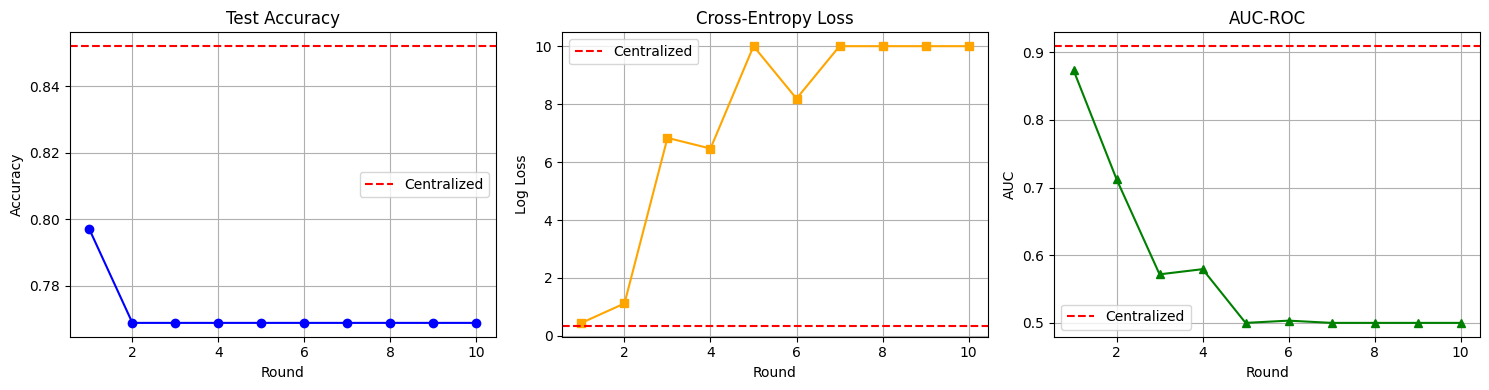

In [ ]:
plt.figure(figsize=(15, 4))

# Accuracy
plt.subplot(1, 3, 1)
plt.plot(range(1, NUM_ROUNDS+1), global_metrics['accuracy'], marker='o', color='blue')
plt.axhline(y=central_metrics['accuracy'], color='r', linestyle='--', label='Centralized')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.legend()
plt.grid(True)

# Log Loss
plt.subplot(1, 3, 2)
plt.plot(range(1, NUM_ROUNDS+1), global_metrics['log_loss'], marker='s', color='orange')
plt.axhline(y=central_metrics['log_loss'], color='r', linestyle='--', label='Centralized')
plt.xlabel('Round')
plt.ylabel('Log Loss')
plt.title('Cross-Entropy Loss')
plt.legend()
plt.grid(True)

# AUC
plt.subplot(1, 3, 3)
plt.plot(range(1, NUM_ROUNDS+1), global_metrics['auc'], marker='^', color='green')
plt.axhline(y=central_metrics['auc'], color='r', linestyle='--', label='Centralized')
plt.xlabel('Round')
plt.ylabel('AUC')
plt.title('AUC-ROC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("GLOBAL RF PERFORMANCE PER ROUND")
print("="*60)
print(f"{'Round':>6} {'Accuracy':>10} {'F1':>10} {'AUC':>10} {'Log Loss':>12}")
print("-"*60)
for r in range(NUM_ROUNDS):
    print(f"{r+1:>6} {global_metrics['accuracy'][r]:>10.4f} "
          f"{global_metrics['f1'][r]:>10.4f} "
          f"{global_metrics['auc'][r]:>10.4f} "
          f"{global_metrics['log_loss'][r]:>12.4f}")

print("-"*60)
print("CENTRALIZED BASELINE:")
print(f"Accuracy: {central_metrics['accuracy']:.4f}  F1: {central_metrics['f1']:.4f}  "
      f"AUC: {central_metrics['auc']:.4f}  LogLoss: {central_metrics['log_loss']:.4f}")
print("="*60)

# --- Optional: Final Global vs Centralised gap ---
final_acc = global_metrics['accuracy'][-1]
gap = central_metrics['accuracy'] - final_acc
print(f"\nAccuracy gap (Centralised - Federated): {gap:.4f}")
if DP_EPSILON is not None:
    print(f"DP noise enabled with ε = {DP_EPSILON}")
else:
    print("No DP noise applied.")


GLOBAL RF PERFORMANCE PER ROUND
 Round   Accuracy         F1        AUC     Log Loss
------------------------------------------------------------
     1     0.7970     0.7297     0.8736       0.4492
     2     0.7689     0.6684     0.7125       1.1202
     3     0.7689     0.6684     0.5718       6.8349
     4     0.7689     0.6684     0.5794       6.4658
     5     0.7689     0.6684     0.5000      10.0000
     6     0.7689     0.6684     0.5033       8.1904
     7     0.7689     0.6684     0.5000      10.0000
     8     0.7689     0.6684     0.5000      10.0000
     9     0.7689     0.6684     0.5000      10.0000
    10     0.7689     0.6684     0.5000      10.0000
------------------------------------------------------------
CENTRALIZED BASELINE:
Accuracy: 0.8521  F1: 0.8358  AUC: 0.9091  LogLoss: 0.3512

Accuracy gap (Centralised - Federated): 0.0832
No DP noise applied.
